In [ ]:
import pandas as pd
import numpy as np
import random
import statsmodels.api as sm
from patsy import dmatrices
from sklearn.model_selection import train_test_split
import pybaseball as pyb
import pylahman as lahman
import os
import glob
import csv
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


In [3]:
CACHE_FILE = "/Users/nzhu/Desktop/Thesis Code/all_pitchers.csv"
if os.path.exists(CACHE_FILE):
        all_pitching_stats = pd.read_csv(CACHE_FILE)
else:
    all_pitching_stats = pyb.bwar_pitch() # bwar pitching stats for ALL years
    all_pitching_stats.to_csv(CACHE_FILE, index=False) # cache to csv to avoid repeated fetching
year = 2023
print(all_pitching_stats[all_pitching_stats["year_ID"] == 2018])

            name_common    mlb_ID  player_ID  year_ID team_ID  stint_ID lg_ID  \
49275        Jason Adam  592094.0   adamja01     2018     KCR         1    AL   
49276      Chance Adams  664856.0  adamsch01     2018     NYY         1    AL   
49277  Victor Alcántara  622505.0  alcanvi01     2018     DET         1    AL   
49278        Cody Allen  592102.0  allenco01     2018     CLE         1    AL   
49279    Miguel Almonte  602083.0  almonmi01     2018     LAA         1    AL   
...                 ...       ...        ...      ...     ...       ...   ...   
50166     Mike Zagurski  489448.0  zagurmi01     2018     MIL         1    NL   
50167     Daniel Zamora  623354.0  zamorda01     2018     NYM         1    NL   
50168     Rob Zastryzny  642239.0  zastrro01     2018     CHC         1    NL   
50169      Brad Ziegler  446899.0  zieglbr01     2018     MIA         1    NL   
50170      Brad Ziegler  446899.0  zieglbr01     2018     ARI         2    NL   

        G  GS  RA     xRA  

In [4]:
from pybaseball import cache
cache.enable()

In [5]:
 #* Get starters!
def get_starters(start_year = 2018, min_starts = 15):
    """Get pool of starters, including salary and bWAR, from starting year and with
    minimum min_starts starts to be qualified"""
    df = pyb.bwar_pitch(return_all = False) # pyright: ignore[reportUndefinedVariable]
    columns = ['name_common','mlb_ID', 'player_ID', 'year_ID', 'team_ID', 'WAR', 'salary', 'GS']
    # only get recent pitchers, only take necessary columns
    pitchers = df[(df['year_ID'] >= start_year) & (df['GS'] >= min_starts)].filter(columns)

    # only get pitchers with salary
    starters_pool = pitchers[pitchers['salary'].notna()]
    return starters_pool

starters_pool = get_starters()
starters_pool

,name_common,mlb_ID,player_ID,year_ID,team_ID,WAR,salary,GS
49283,Brett Anderson,474463.0,anderbr04,2018,OAK,0.59,100000.0,17
49303,Trevor Bauer,545333.0,bauertr01,2018,CLE,6.03,6525000.0,27
49313,José Berríos,621244.0,berrijo01,2018,MIN,3.51,570000.0,32
49322,Matthew Boyd,571510.0,boydma01,2018,DET,2.49,562000.0,31
49333,Dylan Bundy,605164.0,bundydy01,2018,BAL,-0.09,1640000.0,31
...,...,...,...,...,...,...,...,...
56831,Taijuan Walker,592836.0,walketa01,2025,PHI,1.48,18000000.0,21
56834,Logan Webb,657277.0,webblo01,2025,SFG,3.83,12000000.0,34
56837,Zack Wheeler,554430.0,wheelza01,2025,PHI,5.02,42000000.0,24
56842,Trevor Williams,592866.0,willitr01,2025,WSN,-0.57,7000000.0,17


In [6]:
mean_salary = np.mean(starters_pool["salary"]) * 5
std_salary = np.std(starters_pool["salary"]) *np.sqrt(5)
mean_starter_war = np.mean(starters_pool["WAR"])
std_starter_war = np.std(starters_pool["WAR"])

# constraint: mean + std_dev >= budget >= mean - std_dev
floor, ceiling = mean_salary - std_salary, mean_salary + std_salary
print(f"Mean salary: {mean_salary}, Std Dev: {std_salary}")
print(f"Budget should be between {round(floor)} and {round(ceiling)}")

Mean salary: 41949245.920365535, Std Dev: 19290402.968637373
Budget should be between 22658843 and 61239649


In [7]:
# get offensive information
batters = pyb.bwar_bat(return_all = False)
columns = ['name_common','mlb_ID', 'player_ID', 'year_ID', 'team_ID', 'WAR', 'salary', 'GS']
batters = batters[(batters['year_ID'] >= 2018) & (batters['PA'] >= 300)].filter(columns)

# salary and WAR of offensive starters by team
team_offenses = batters.groupby(by = ['team_ID', 'year_ID'], dropna = True)[['salary', 'WAR']].sum().reset_index()

print(team_offenses)

# get some correlation/regression/training of salary to war
data = team_offenses
X = data['salary'].values.reshape(-1,1)
y = data['WAR'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=60)

lr = LinearRegression()
lr.fit(X_train, y_train)


    team_ID  year_ID      salary    WAR
0       ARI     2018  33225000.0  19.17
1       ARI     2019  27099466.0  21.41
2       ARI     2021  32891667.0  11.77
3       ARI     2022  21825000.0  20.65
4       ARI     2023  28485471.0  24.54
..      ...      ...         ...    ...
205     WSN     2021  42850000.0  21.75
206     WSN     2022  45450000.0  11.88
207     WSN     2023  13482900.0  14.43
208     WSN     2024  15869400.0  11.36
209     WSN     2025  20800000.0  10.08

[210 rows x 4 columns]


LinearRegression()

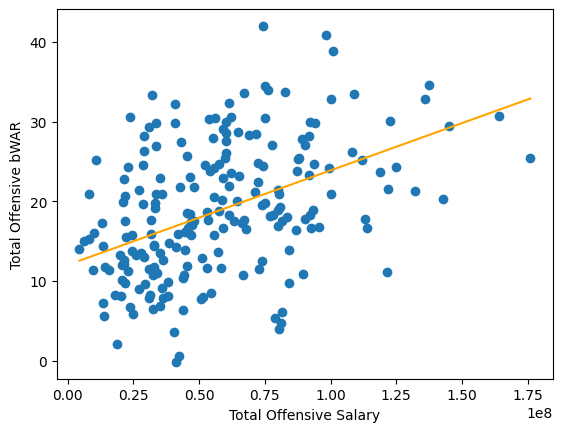

[1.18753134e-07] 12.010263586464038


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of all data
plt.figure()
plt.scatter(X, y)

# Create smooth line for regression
x_range = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_pred_line = lr.predict(x_range)

# Plot regression line
plt.plot(x_range, y_pred_line, color='orange', label='Regression Line')

plt.xlabel("Total Offensive Salary")
plt.ylabel("Total Offensive bWAR")
plt.show()
print(lr.coef_, lr.intercept_)
offense_coef = lr.coef_[0]
offense_intercept = lr.intercept_

In [9]:
def get_offense_war(offense_payroll):
    """ Get a team's offense war given the cost of the rotation
    """
    y_pred = lr.predict(np.array([[offense_payroll]]))[0]
    return y_pred


In [10]:
# Map for abbreviations
retro_to_bref = {
    # AL East
    "BAL": "BAL",  # Baltimore Orioles
    "BOS": "BOS",  # Boston Red Sox
    "NYA": "NYY",  # New York Yankees
    "TBA": "TBR",  # Tampa Bay Rays
    "TOR": "TOR",  # Toronto Blue Jays

    # AL Central
    "CHA": "CHW",  # Chicago White Sox
    "CLE": "CLE",  # Cleveland Guardians (formerly Indians)
    "DET": "DET",  # Detroit Tigers
    "KCA": "KCR",  # Kansas City Royals
    "MIN": "MIN",  # Minnesota Twins

    # AL West
    "HOU": "HOU",  # Houston Astros
    "LAA": "LAA",  # Los Angeles Angels
    "CAL": "LAA",  # California Angels (historical)
    "ANA": "LAA",  # Anaheim Angels (historical)
    "OAK": "OAK",  # Oakland Athletics
    "SEA": "SEA",  # Seattle Mariners
    "TEX": "TEX",  # Texas Rangers

    # NL East
    "ATL": "ATL",  # Atlanta Braves
    "MIA": "MIA",  # Miami Marlins
    "FLO": "MIA",  # Florida Marlins (historical)
    "NYN": "NYM",  # New York Mets
    "PHI": "PHI",  # Philadelphia Phillies
    "WAS": "WSN",  # Washington Nationals
    "MON": "WSN",  # Montreal Expos (historical → Nationals)

    # NL Central
    "CHN": "CHC",  # Chicago Cubs
    "CIN": "CIN",  # Cincinnati Reds
    "MIL": "MIL",  # Milwaukee Brewers
    "PIT": "PIT",  # Pittsburgh Pirates
    "SLN": "STL",  # St. Louis Cardinals

    # NL West
    "ARI": "ARI",  # Arizona Diamondbacks
    "COL": "COL",  # Colorado Rockies
    "LAN": "LAD",  # Los Angeles Dodgers
    "SDN": "SDP",  # San Diego Padres
    "SFN": "SFG",  # San Francisco Giants

    # Historical / Defunct (mapped to modern equivalents if possible)
    "MLN": "ATL",  # Milwaukee Braves → Atlanta Braves
    "WS1": "MIN",  # Washington Senators (original) → Minnesota Twins
    "WS2": "TEX",  # Washington Senators (expansion) → Texas Rangers
    "KC1": "OAK",  # Kansas City Athletics → Oakland Athletics
    "PHA": "OAK",  # Philadelphia Athletics → Oakland Athletics
    "SLA": "BAL",  # St. Louis Browns → Baltimore Orioles
    "BLA": "NYY",  # Baltimore Orioles (AL, 1901–02) → defunct (sometimes linked to Yankees lineage)
    "SE1": "MIL",  # Seattle Pilots → Milwaukee Brewers
}

def get_bref_name(retro_name: str) -> str:
    """Convert Retrosheet team abbreviation to Baseball Reference abbreviation."""
    return retro_to_bref.get(retro_name, retro_name)  # default to input if not found

In [11]:
print(team_offenses)

    team_ID  year_ID      salary    WAR
0       ARI     2018  33225000.0  19.17
1       ARI     2019  27099466.0  21.41
2       ARI     2021  32891667.0  11.77
3       ARI     2022  21825000.0  20.65
4       ARI     2023  28485471.0  24.54
..      ...      ...         ...    ...
205     WSN     2021  42850000.0  21.75
206     WSN     2022  45450000.0  11.88
207     WSN     2023  13482900.0  14.43
208     WSN     2024  15869400.0  11.36
209     WSN     2025  20800000.0  10.08

[210 rows x 4 columns]


In [12]:
logs = pyb.season_game_logs(2021)
# find columns in logs that corresponds to starting pitcher pitches thrown
print(list(logs.columns))


['date', 'game_num', 'day_of_week', 'visiting_team', 'visiting_team_league', 'visiting_team_game_num', 'home_team', 'home_team_league', 'home_team_game_num', 'visiting_score', 'home_score', 'num_outs', 'day_night', 'completion_info', 'forfeit_info', 'protest_info', 'park_id', 'attendance', 'time_of_game_minutes', 'visiting_line_score', 'home_line_score', 'visiting_abs', 'visiting_hits', 'visiting_doubles', 'visiting_triples', 'visiting_homeruns', 'visiting_rbi', 'visiting_sac_hits', 'visiting_sac_flies', 'visiting_hbp', 'visiting_bb', 'visiting_iw', 'visiting_k', 'visiting_sb', 'visiting_cs', 'visiting_gdp', 'visiting_ci', 'visiting_lob', 'visiting_pitchers_used', 'visiting_individual_er', 'visiting_er', 'visiting_wp', 'visiting_balks', 'visiting_po', 'visiting_assists', 'visiting_errors', 'visiting_pb', 'visiting_dp', 'visiting_tp', 'home_abs', 'home_hits', 'home_doubles', 'home_triples', 'home_homeruns', 'home_rbi', 'home_sac_hits', 'home_sac_flies', 'home_hbp', 'home_bb', 'home_iw',

In [13]:

# df columns needed (example):
# df['team_runs_allowed'] - integer runs for team in game
# df['pitcher_war_scaled'] - standardized pitcher WAR or per-game WAR
# df['opp_off_war_scaled'] - standardized opponent offense WAR
# df['days_rest'] - numeric
# df['home'] - 1 if home, 0 if away

model_data = pd.DataFrame({
    'pitcher_name': pd.Series(dtype='str'),
    'team_runs_allowed': pd.Series(dtype='float'),
    'pitcher_war': pd.Series(dtype='float'),
    'opp_off_war': pd.Series(dtype='float'),
    'days_rest': pd.Series(dtype='float'),
    'home': pd.Series(dtype='int'),
    'date': pd.Series(dtype='int')
})
team_off_war_means = team_offenses.groupby('year_ID')['WAR'].mean().to_dict()
team_off_war_stds = team_offenses.groupby('year_ID')['WAR'].std().to_dict()
years = [2018, 2019, 2021, 2022, 2023,] # loop through year 
debug = False
for year in years:
    logs = pyb.season_game_logs(year)
    pitching_stats = pyb.bwar_pitch() # bwar pitching stats for ALL years
    team_batting_stats = pyb.team_batting(year) # team batting stats for the year (fangraphs)

    df = pd.DataFrame({
        'date': pd.to_datetime(logs['date'].astype(str), format='%Y%m%d'),
        'raw_date': logs['date'],
        'pitcher': logs['visiting_starting_pitcher_name']
    }).assign(role='away_starter')

    home = pd.DataFrame({
        'date': pd.to_datetime(logs['date'].astype(str), format='%Y%m%d'),
        'raw_date': logs['date'],
        'pitcher': logs['home_starting_pitcher_name']
    }).assign(role='home_starter')

    pitchers = pd.concat([df, home], ignore_index=True)

    pitchers['days_rest'] = (
        pitchers.sort_values(['pitcher', 'date'])
        .groupby('pitcher')['date']
        .diff()
        .dt.days
    )

    for i in range(len(logs)):
        # get info from retrosheet logs
        date = logs['date'].iloc[i]
        game_id = logs["home_team"].iloc[i] + str(date) + str(logs["game_num"].iloc[i])
        home_starting_pitcher = logs['home_starting_pitcher_name'].iloc[i]
        away_starting_pitcher = logs['visiting_starting_pitcher_name'].iloc[i]
        
        home_runs = logs['home_score'].iloc[i]
        away_runs = logs['visiting_score'].iloc[i] 
        park = logs['park_id'].iloc[i] # ignore park factor for now

        # get pitcher WARs (from bWar)
        home_pitcher_stats = pitching_stats[(pitching_stats['name_common'] == home_starting_pitcher) & (pitching_stats['year_ID'] == year)]
        away_pitcher_stats = pitching_stats[(pitching_stats['name_common'] == away_starting_pitcher) & (pitching_stats['year_ID'] == year)]
        home_pitcher_war = home_pitcher_stats['WAR'].values[0] if not home_pitcher_stats.empty else None
        away_pitcher_war = away_pitcher_stats['WAR'].values[0] if not away_pitcher_stats.empty else None

        # get offense values
        home_offense_value = team_offenses[(team_offenses['team_ID'] == get_bref_name(logs['home_team'].iloc[i])) & (team_offenses['year_ID'] == year)]['WAR'].values[0]
        away_offense_value = team_offenses[(team_offenses['team_ID'] == get_bref_name(logs['visiting_team'].iloc[i])) & (team_offenses['year_ID'] == year)]['WAR'].values[0]
        
        # print info
        if debug == True:
            print(date)
            print(f"Home team starting pitcher: {home_starting_pitcher} (WAR: {home_pitcher_war}), batting value: {home_offense_value}")
            print(f"Away team starting pitcher: {away_starting_pitcher} (WAR: {away_pitcher_war}), batting value: {away_offense_value}")
            print(f"Home runs: {home_runs}, Away runs: {away_runs}")

        ## add information to the model_data dataframe
        rows = []
        home_rest_days = pitchers[(pitchers['pitcher'] == home_starting_pitcher) & (pitchers['raw_date'] == date)]['days_rest'].iloc[0]
        # add home row only if home pitcher's WAR is present
        if home_pitcher_war is not None:
            rows.append({
                'pitcher_name': home_starting_pitcher,
                'team_runs_allowed': away_runs,
                'pitcher_war': home_pitcher_war,
                'opp_off_war': away_offense_value,  # opponent for home is away
                'days_rest': home_rest_days if not np.isnan(home_rest_days) else 6, 
                'home': 1,
                'date': date,
                'game_id': game_id
            })
        away_rest_days = pitchers[(pitchers['pitcher'] == away_starting_pitcher) & (pitchers['raw_date'] == date)]['days_rest'].iloc[0]
        # add away row only if away pitcher's WAR is present
        if away_pitcher_war is not None:
            rows.append({
                'pitcher_name': away_starting_pitcher,
                'team_runs_allowed': home_runs,
                'pitcher_war': away_pitcher_war,
                'opp_off_war': home_offense_value,  # opponent for away is home
                'days_rest': away_rest_days if not np.isnan(away_rest_days) else 6,
                'home': 0,
                'date': date,
                'game_id': game_id
            })

        if rows:
            new_data = pd.DataFrame(rows)
            model_data = pd.concat([model_data, new_data], ignore_index=True)
model_data

,pitcher_name,team_runs_allowed,pitcher_war,opp_off_war,days_rest,home,date,game_id
0,Patrick Corbin,2.0,4.38,16.91,6.0,1,20180329,ARI201803290
1,Jon Gray,8.0,1.26,19.17,6.0,0,20180329,ARI201803290
2,Julio Teheran,5.0,1.86,6.52,6.0,1,20180329,ATL201803290
3,Aaron Nola,8.0,9.69,27.47,6.0,0,20180329,ATL201803290
4,Clayton Kershaw,1.0,3.29,10.93,6.0,1,20180329,LAN201803290
...,...,...,...,...,...,...,...,...
21354,Michael King,5.0,3.27,6.77,5.0,0,20231001,KCA202310010
21355,George Kirby,0.0,3.76,34.44,5.0,1,20231001,SEA202310010
21356,Dane Dunning,1.0,2.66,21.76,4.0,0,20231001,SEA202310010
21357,Wes Parsons,12.0,-0.35,33.39,6.0,1,20231001,TOR202310010


In [14]:
def parse_eba_file(filepath):
    rows = []
  
    with open(filepath, "r") as f:
        lines = f.read().splitlines()

    current_game_id = None

    for line in lines:
        # Game ID line
        if line.startswith("id,"):
            current_game_id = line.split(",")[1]
            continue
        
        # Only collect pitching lines
        if line.startswith("stat,pline"):
            parts = line.split(",")
            
            # Unpack schema
            (_stat, _pline, 
                pitcher_id, side, seq, ip3,
                no_out, bfp, h, b2, b3,hr,
                r, er, bb, ibb, k, hbp, wp,
                balk, sh, sf
            ) = parts
            if seq == "1":
                game_id = current_game_id
                year = int(game_id[3:7])
                home_team = game_id[0:3]

                rows.append({
                    "game_id": game_id,
                    "player_id": pitcher_id,
                   "side": side,
                    "seq": int(seq),
                    # Pitching stats
                    "outs_recorded": int(ip3),   # IP expressed as outs
                    "pitches": int(bfp) * 3.9,
                    "H": int(h),
                    "R": int(r),
                    "ER": int(er),
                    "BB": int(bb),
                    "K": int(k),
                    "WP": int(wp),
                    "home_team": home_team,
                    "year": year
                })

    return pd.DataFrame(rows)
def load_all_eba(directory):
    dfs = []
    for file in glob.glob(f"{directory}/*.EBA"):
        dfs.append(parse_eba_file(file))
    return pd.concat(dfs, ignore_index=True)

all_pitching = pd.concat([load_all_eba("2020sbox"), load_all_eba("2010sbox")], ignore_index=True)

In [15]:
def pitcher_pitchcount_last_n_days(all_pitching, days=20):

    all_pitching["date"] = pd.to_datetime(
        all_pitching["game_id"].str[3:11], format="%Y%m%d"
    )

    cutoff = all_pitching["date"].max() - pd.Timedelta(days=days)

    recent = all_pitching[all_pitching["date"] >= cutoff]

    pitch_count = (
        recent.groupby("player_id")
        .agg(
            pitches_last_n=("est_pitches","sum"),
            IP_last_n=("IP","sum"),
            appearances=("game_id","count")
        )
        .reset_index()
    )

    return pitch_count

In [16]:
# not using right now 
"""
def pitcher_workload_last_n_days(all_pitching, days=20):
    
    # ensure date exists
    all_pitching["date"] = pd.to_datetime(
        all_pitching["game_id"].str[3:11], format="%Y%m%d"
    )

    latest_date = all_pitching["date"].max()
    cutoff = latest_date - pd.Timedelta(days=days)

    recent = all_pitching[all_pitching["date"] >= cutoff]

    workload = (
        recent.groupby("player_id")
        .agg(
            outs_last_n=("outs_recorded","sum"),
            bf_last_n=("BFP","sum"),
            appearances=("game_id","count")
        )
        .reset_index()
    )

    workload["IP_last_n"] = workload["outs_last_n"] / 3

    return workload
    """

'\ndef pitcher_workload_last_n_days(all_pitching, days=20):\n    \n    # ensure date exists\n    all_pitching["date"] = pd.to_datetime(\n        all_pitching["game_id"].str[3:11], format="%Y%m%d"\n    )\n\n    latest_date = all_pitching["date"].max()\n    cutoff = latest_date - pd.Timedelta(days=days)\n\n    recent = all_pitching[all_pitching["date"] >= cutoff]\n\n    workload = (\n        recent.groupby("player_id")\n        .agg(\n            outs_last_n=("outs_recorded","sum"),\n            bf_last_n=("BFP","sum"),\n            appearances=("game_id","count")\n        )\n        .reset_index()\n    )\n\n    workload["IP_last_n"] = workload["outs_last_n"] / 3\n\n    return workload\n    '

In [17]:
def load_rosters(path="2020sbox"):
    rows = []
    i = 0
    for file in glob.glob(f"{path}/*.ROS"):
        i+=1
        basename = os.path.basename(file)     # ANA2020.ROS
        stem = basename.split(".")[0]          # ANA2020
        year = int(stem[3:7])                  # 2020
        with open(file, newline="") as f:
            reader = csv.reader(f)
            for row in reader:
                # Row format:
                # [player_id, Lastname, Firstname, Pitch side, Hit side, Team, Position]
                player_id = row[0]
                last = row[1]
                first = row[2]
                team = row[5]
                rows.append({
                    "player_id": player_id,
                    "pitcher_name": f"{first} {last}",
                    "team": team,
                    "year": year,
                })
    return pd.DataFrame(rows)


rosters = pd.concat([load_rosters("2020sbox"), load_rosters("2010sbox")], ignore_index=True)
print(rosters)
pitching = all_pitching.merge(
    rosters[["player_id", "pitcher_name", "team", "year", ]],
    on=["player_id", "year"],
    how="left"
)
pitching["game_date"] = pd.to_datetime(
    pitching["game_id"].str[3:11],
    format="%Y%m%d"
)

pitching["IP"] = pitching["outs_recorded"] / 3

def add_last_20_day_workload(df):
    df = df.sort_values("game_date").copy()

    ip_last_20 = []
    pitches_last_20 = []

    for _, row in df.iterrows():
        current_date = row["game_date"]
        cutoff = current_date - pd.Timedelta(days=20)

        prior_window = df[
            (df["game_date"] < current_date) &
            (df["game_date"] >= cutoff)
        ]

        ip_last_20.append(prior_window["IP"].sum())
        pitches_last_20.append(prior_window["pitches"].sum())

    df["IP_last_20"] = ip_last_20
    df["pitches_last_20"] = pitches_last_20
    return df


pitching_with_workload = (
    pitching.groupby("player_id", group_keys=False)
    .apply(add_last_20_day_workload, include_groups=False)
)


pitcher_game_stats = pitching_with_workload[
    ["game_id", "pitcher_name", "ER", "pitches", "IP_last_20", "pitches_last_20"]
].drop_duplicates()

individual_er_model = model_data.merge(
    pitcher_game_stats,
    on=["game_id", "pitcher_name"],
    how="left"
)

individual_er_model = individual_er_model.dropna(subset=["ER"])

#individual_er_model["days_rest_scaled"] = (individual_er_model["days_rest"] - individual_er_model["days_rest"].mean()) / individual_er_model["days_rest"].std()
individual_er_model

      player_id    pitcher_name team  year
0      adamr004     Riley Adams  TOR  2021
1      allgn001   Nick Allgeyer  TOR  2021
2      bakeb001     Bryan Baker  TOR  2021
3      barnj002    Jacob Barnes  TOR  2021
4      beasj001  Jeremy Beasley  TOR  2021
...         ...             ...  ...   ...
24264  utlec001     Chase Utley  LAN  2018
24265  valeb001  Breyvic Valera  LAN  2018
24266  vendp001    Pat Venditte  LAN  2018
24267  verda001    Alex Verdugo  LAN  2018
24268  wooda002       Alex Wood  LAN  2018

[24269 rows x 4 columns]


,pitcher_name,team_runs_allowed,pitcher_war,opp_off_war,days_rest,home,date,game_id,ER,pitches,IP_last_20,pitches_last_20
10,Dylan Bundy,2.0,-0.09,17.47,6.0,1,20180329,BAL201803290,0.0,101.4,0.000000,0.0
11,Jake Odorizzi,3.0,1.28,4.78,6.0,0,20180329,BAL201803290,0.0,85.8,0.000000,0.0
12,Danny Duffy,14.0,1.43,13.23,6.0,1,20180329,KCA201803290,5.0,78.0,0.000000,0.0
13,James Shields,7.0,1.31,6.81,6.0,0,20180329,KCA201803290,4.0,97.5,0.000000,0.0
14,Kendall Graveman,5.0,-0.88,26.24,6.0,1,20180329,OAK201803290,5.0,85.8,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
21353,Zack Greinke,2.0,1.09,11.14,5.0,1,20231001,KCA202310010,1.0,74.1,10.666667,163.8
21355,George Kirby,0.0,3.76,34.44,5.0,1,20231001,SEA202310010,0.0,78.0,19.000000,296.4
21356,Dane Dunning,1.0,2.66,21.76,4.0,0,20231001,SEA202310010,1.0,58.5,23.333333,378.3
21357,Wes Parsons,12.0,-0.35,33.39,6.0,1,20231001,TOR202310010,9.0,101.4,0.000000,0.0


In [18]:
# --------- Create/train the model ---------
# Model formul
predictors = ["pitcher_war", "opp_off_war", "days_rest", "home", "pitches_last_20"]

formula_er = "ER ~ pitcher_war + opp_off_war + days_rest + home + pitches_last_20"
formula_pitches = "pitches ~ pitcher_war + opp_off_war + days_rest + home + pitches_last_20"
# Design matrices
train_data, test_data = train_test_split(individual_er_model, test_size=0.2, random_state=42)

y_train_er, X_train = dmatrices(formula_er, data=train_data, return_type="dataframe")
y_test_er, X_test = dmatrices(formula_er, data=test_data, return_type="dataframe")

y_train_p, _ = dmatrices(formula_pitches, data=train_data, return_type="dataframe")
y_test_p, _ = dmatrices(formula_pitches, data=test_data, return_type="dataframe")
# scale numeric predictors so we can feed raw values later without manual scaling
scale_columns = ["pitcher_war", "opp_off_war", "days_rest", "pitches_last_20"]
scaling_params = {}
for col in scale_columns:
    mean_val = X_train[col].mean()
    std_val = X_train[col].std()
    scaling_params[col] = (mean_val, std_val)
    if col == "days_rest":
        # only do days rest above average
        X_train[col] = X_train[col] - mean_val
        X_test[col] = X_test[col] - mean_val
    else:
        X_train[col] = (X_train[col] - mean_val) / std_val
        X_test[col] = (X_test[col] - mean_val) / std_val

er_model = sm.NegativeBinomial(y_train_er, X_train)
er_res = er_model.fit()
print(er_res.summary())

pitches_model = sm.OLS(y_train_p, X_train)
pitches_res = pitches_model.fit()

print(pitches_res.summary())

er_pred = er_res.predict(X_test)
pitches_pred = pitches_res.predict(X_test)

print("ER MSE:", np.mean((y_test_er.values.flatten() - er_pred) ** 2))
print("Pitches MSE:", np.mean((y_test_p.values.flatten() - pitches_pred) ** 2))

# keep scaling_params available for downstream simulation
pitcher_war_mean, pitcher_war_std = scaling_params['pitcher_war']
opp_off_war_mean, opp_off_war_std = scaling_params['opp_off_war']
days_rest_mean, days_rest_std = scaling_params['days_rest']
pitches_last_20_mean, pitches_last_20_std = scaling_params['pitches_last_20']


Optimization terminated successfully.
         Current function value: 1.964553
         Iterations: 14
         Function evaluations: 15
         Gradient evaluations: 15
                     NegativeBinomial Regression Results                      
Dep. Variable:                     ER   No. Observations:                 8324
Model:               NegativeBinomial   Df Residuals:                     8318
Method:                           MLE   Df Model:                            5
Date:                Sat, 28 Mar 2026   Pseudo R-squ.:                 0.01256
Time:                        23:42:09   Log-Likelihood:                -16353.
converged:                       True   LL-Null:                       -16561.
Covariance Type:            nonrobust   LLR p-value:                 1.078e-87
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.9082  

In [19]:
print(opp_off_war_mean, opp_off_war_std )

19.308195579048533 8.91342872401626


In [20]:
from scipy.stats import nbinom

# --------- Negative binomial simulation ---------
def simulate_runs_allowed(mu, alpha=0.2313):
    """
    Simulate runs allowed given expected runs allowed (mu)
    and NB dispersion parameter alpha.
    """
    var = mu + alpha * mu**2
    p = mu / var
    r = mu**2 / (var - mu)
    return nbinom.rvs(r, p)


# --------- Model setup ---------
coeff_names = [
    'Intercept',
    'pitcher_war',
    'opp_off_war',
    'days_rest',
    'home',
    'pitches_last_20'
]

coeffs = er_res.params[coeff_names].values
link_func = np.exp  # log link


# --------- Scaling info ---------
scaling_params = {
    'pitcher_war': (pitcher_war_mean, pitcher_war_std),
    'opp_off_war': (opp_off_war_mean, opp_off_war_std),
    'days_rest': (days_rest_mean, days_rest_std),
    'pitches_last_20': (pitches_last_20_mean, pitches_last_20_std),
    # home is not scaled
}

# --------- Feature vector builder ---------
def build_feature_vector(features):
    """
    Build model-ready feature vector from a dict.

    Expected keys in features:
        pitcher_war
        opp_off_war
        days_rest
        home
        pitches_last_20
    """
    x = [1.0]  # intercept

    for name in coeff_names[1:]:
        value = features[name]

        if name in scaling_params:
            mean_val, std_val = scaling_params[name]
            value = (value - mean_val) / std_val

        x.append(value)

    return np.array(x, dtype=float)


# --------- Predict expected runs allowed ---------
def predict_mu(features):
    """
    Return expected runs allowed mu from a feature dictionary.
    """
    x = build_feature_vector(features)
    return link_func(x.dot(coeffs))


# --------- Cached version ---------
_predict_cache = {}

def predict_mu_cached(features, q=3):
    """
    Quantize numeric inputs and cache predictions.
    """
    key = tuple(
        int(features[name]) if name == 'home' else round(features[name], q)
        for name in coeff_names[1:]
    )

    v = _predict_cache.get(key)
    if v is None:
        v = predict_mu(features)
        _predict_cache[key] = v
    return v


# --------- Simulate one game ---------
def simulate_game(team1_pitcher_war, team2_pitcher_war,
                  team1_off_war, team2_off_war,
                  team1_rest_days, team2_rest_days,
                  team1_pitches_last_20, team2_pitches_last_20,
                  home):
    """
    Simulate a game between two teams.

    Inputs
    ------
    team1_pitcher_war : float
    team2_pitcher_war : float
    team1_off_war : float
    team2_off_war : float
    team1_rest_days : float/int
    team2_rest_days : float/int
    team1_pitches_last_20 : float
    team2_pitches_last_20 : float
    home : int
        1 if team 1 is home, 0 if team 2 is home

    Returns
    -------
    team1_mu : expected runs allowed by team 1
    team2_mu : expected runs allowed by team 2
    team1_runs_allowed : simulated runs allowed by team 1
    team2_runs_allowed : simulated runs allowed by team 2
    """

    team1_features = {
        'pitcher_war': team1_pitcher_war,
        'opp_off_war': team2_off_war,
        'days_rest': team1_rest_days,
        'home': home,
        'pitches_last_20': team1_pitches_last_20
    }

    team2_features = {
        'pitcher_war': team2_pitcher_war,
        'opp_off_war': team1_off_war,
        'days_rest': team2_rest_days,
        'home': home ^ 1,
        'pitches_last_20': team2_pitches_last_20
    }

    team1_mu = predict_mu_cached(team1_features)
    team2_mu = predict_mu_cached(team2_features)



    return team1_mu, team2_mu

In [21]:

def prune_pitch_log(pitch_log, current_day, window=20):
    """Keep only outings within the last `window` days."""
    return [(day, pitches) for day, pitches in pitch_log if current_day - day < window]

def get_pitches_last_20(pitch_log, current_day, window=20):
    """Total pitches thrown in the last `window` days."""
    pitch_log = prune_pitch_log(pitch_log, current_day, window)
    return sum(pitches for day, pitches in pitch_log)

def get_days_rest(pitch_log, current_day):
    """
    Days since last outing.
    If no prior outing exists, return a default fresh-rest value.
    """
    if not pitch_log:
        return 5
    last_day = max(day for day, _ in pitch_log)
    return max(0, current_day - last_day)

def record_pitch_outing(workload_state, pitcher_id, current_day, pitches_thrown, window=20):
    """Append a new outing and prune old ones."""
    workload_state[pitcher_id].append((current_day, pitches_thrown))
    workload_state[pitcher_id] = prune_pitch_log(workload_state[pitcher_id], current_day, window)

In [22]:
def simulate_pitch_count(mu_er, base=90, sd=12):
    """
    Rough pitch count simulator.
    You can replace this later with a trained pitches model.
    """
    pitches = np.random.normal(loc=base + 2 * mu_er, scale=sd)
    return int(np.clip(round(pitches), 50, 120))

In [23]:
def simulate_series(pitchers,
                    off_war: float | None,
                    opponent_difficulty: str,
                    series_length=5,
                    alpha=0.2313,
                    n_series=1000,
                    home=True,
                    workload_state=None,
                    current_day=0,
                    pitcher_ids=None):
    """
    Simulate a playoff series.

    Parameters
    ----------
    pitchers : array-like
        Your rotation WAR values.
    off_war : float
        Your team's offensive WAR.
    opponent_difficulty : str
        One of {"average", "hard", "hardest"}.
    series_length : int
        3, 5, or 7.
    workload_state : dict
        Maps pitcher_id -> list of (day, pitches_thrown).
        This is preserved across rounds.
    current_day : int
        Current day in the postseason timeline.
    pitcher_ids : list[str] | None
        Stable IDs for your pitchers. Must line up with `pitchers`.

    Returns
    -------
    if n_series == 1:
        (won_series: bool, workload_state: dict, current_day: int)
    else:
        home_series_win_prob: float
    """
    assert series_length in [3, 5, 7], "Series length must be 3, 5, or 7"
    assert opponent_difficulty in ["average", "hard", "hardest"], \
        "Opponent difficulty must be 'average', 'hard', or 'hardest'"

    pitchers = np.array(pitchers)

    if pitcher_ids is None:
        pitcher_ids = [f"home_{i}" for i in range(len(pitchers))]

    if workload_state is None:
        workload_state = {pid: [] for pid in pitcher_ids}

    # opponent parameters
    match opponent_difficulty:
        case "average":
            mean_dist_starter_war = mean_starter_war
            mean_dist_off_war = opp_off_war_mean
        case "hard":
            mean_dist_starter_war = mean_starter_war + 1
            mean_dist_off_war = opp_off_war_mean + opp_off_war_std / 2
        case "hardest":
            mean_dist_starter_war = mean_starter_war + 1.5
            mean_dist_off_war = opp_off_war_mean + opp_off_war_std

    wins_needed = series_length // 2 + 1

    if home:
        home_pattern = (
            [1, 1, 1] if series_length == 3
            else [1, 1, 0, 0, 1] if series_length == 5
            else [1, 1, 0, 0, 0, 1, 1]
        )
    else:
        home_pattern = (
            [0, 0, 0] if series_length == 3
            else [0, 0, 1, 1, 0] if series_length == 5
            else [0, 0, 1, 1, 1, 0, 0]
        )

    # for multi-series estimates, average many independent replications
    if n_series > 1:
        home_wins_total = 0
        for _ in range(n_series):
            # fresh opponent each series
            opp_pitchers = [np.random.normal(mean_dist_starter_war, std_starter_war)
                            for _ in range(series_length)]
            opp_ids = [f"opp_{i}" for i in range(series_length)]
            opp_workload_state = {pid: [] for pid in opp_ids}
            opp_off_war = np.random.normal(mean_dist_off_war, opp_off_war_std)

            # deep-ish copy your workload state so each replicated series is independent
            sim_workload = {k: v.copy() for k, v in workload_state.items()}
            sim_day = current_day

            home_wins = 0
            away_wins = 0
            game = 0

            while home_wins < wins_needed and away_wins < wins_needed:
                sim_day += 1

                home_idx = game % len(pitchers)
                away_idx = game % len(opp_pitchers)

                home_pitcher = pitchers[home_idx]
                away_pitcher = opp_pitchers[away_idx]

                home_pid = pitcher_ids[home_idx]
                away_pid = opp_ids[away_idx]

                home_rest = get_days_rest(sim_workload[home_pid], sim_day)
                away_rest = get_days_rest(opp_workload_state[away_pid], sim_day)

                home_p20 = get_pitches_last_20(sim_workload[home_pid], sim_day)
                away_p20 = get_pitches_last_20(opp_workload_state[away_pid], sim_day)

                home_flag = home_pattern[game]

                home_mu, away_mu = simulate_game(
                    team1_pitcher_war=home_pitcher,
                    team2_pitcher_war=away_pitcher,
                    team1_off_war=off_war,
                    team2_off_war=opp_off_war,
                    team1_rest_days=home_rest,
                    team2_rest_days=away_rest,
                    team1_pitches_last_20=home_p20,
                    team2_pitches_last_20=away_p20,
                    home=home_flag
                )

                home_runs_allowed = simulate_runs_allowed(home_mu, alpha)
                away_runs_allowed = simulate_runs_allowed(away_mu, alpha)

                # simulate pitch counts and record workloads
                home_pitch_count = simulate_pitch_count(home_mu)
                away_pitch_count = simulate_pitch_count(away_mu)

                record_pitch_outing(sim_workload, home_pid, sim_day, home_pitch_count)
                record_pitch_outing(opp_workload_state, away_pid, sim_day, away_pitch_count)

                if home_runs_allowed > away_runs_allowed:
                    away_wins += 1
                elif away_runs_allowed > home_runs_allowed:
                    home_wins += 1
                else:
                    if np.random.rand() < 0.5:
                        home_wins += 1
                    else:
                        away_wins += 1

                game += 1

            if home_wins > away_wins:
                home_wins_total += 1

        home_series_win_prob = home_wins_total / n_series
        return home_series_win_prob if home else 1 - home_series_win_prob

    # n_series == 1 case: preserve workload state for downstream rounds
    opp_pitchers = [np.random.normal(mean_dist_starter_war, std_starter_war)
                    for _ in range(series_length)]
    opp_ids = [f"opp_{i}" for i in range(series_length)]
    opp_workload_state = {pid: [] for pid in opp_ids}
    opp_off_war = np.random.normal(mean_dist_off_war, opp_off_war_std)

    home_wins = 0
    away_wins = 0
    game = 0

    while home_wins < wins_needed and away_wins < wins_needed:
        current_day += 1

        home_idx = game % len(pitchers)
        away_idx = game % len(opp_pitchers)

        home_pitcher = pitchers[home_idx]
        away_pitcher = opp_pitchers[away_idx]

        home_pid = pitcher_ids[home_idx]
        away_pid = opp_ids[away_idx]

        home_rest = get_days_rest(workload_state[home_pid], current_day)
        away_rest = get_days_rest(opp_workload_state[away_pid], current_day)

        home_p20 = get_pitches_last_20(workload_state[home_pid], current_day)
        away_p20 = get_pitches_last_20(opp_workload_state[away_pid], current_day)

        home_flag = home_pattern[game]

        home_mu, away_mu = simulate_game(
            team1_pitcher_war=home_pitcher,
            team2_pitcher_war=away_pitcher,
            team1_off_war=off_war,
            team2_off_war=opp_off_war,
            team1_rest_days=home_rest,
            team2_rest_days=away_rest,
            team1_pitches_last_20=home_p20,
            team2_pitches_last_20=away_p20,
            home=home_flag
        )

        home_runs_allowed = simulate_runs_allowed(home_mu, alpha)
        away_runs_allowed = simulate_runs_allowed(away_mu, alpha)

        home_pitch_count = simulate_pitch_count(home_mu)
        away_pitch_count = simulate_pitch_count(away_mu)

        record_pitch_outing(workload_state, home_pid, current_day, home_pitch_count)
        record_pitch_outing(opp_workload_state, away_pid, current_day, away_pitch_count)

        if home_runs_allowed > away_runs_allowed:
            away_wins += 1
        elif away_runs_allowed > home_runs_allowed:
            home_wins += 1
        else:
            if np.random.rand() < 0.5:
                home_wins += 1
            else:
                away_wins += 1

        game += 1

    won_series = home_wins > away_wins
    return won_series, workload_state, current_day

In [24]:
from multiprocessing import Pool, cpu_count

def _worker_champ(args):
    rotation_vals, offense_war, its = args
    wins = 0
    for _ in range(its):
        # reproduce same logic as get_championship_prob but count wins only
        if not simulate_series(rotation_vals, [5,5,5], offense_war, "average", 3, n_series=1, home=True):
            continue
        if not simulate_series(rotation_vals, [5,5,5,3,3], offense_war, "hard", 5, n_series=1, home=True):
            continue
        if not simulate_series(rotation_vals, [4,4,4,5,3,3,3], offense_war, "hard", 7, n_series=1, home=True):
            continue
        if simulate_series(rotation_vals, [4,4,4,5,3,3,3], offense_war, "hardest", 7, n_series=1, home=True):
            wins += 1
    return wins

def get_championship_prob_parallel(rotation, offense_war, num_iter=1000):
    rotation_vals = rotation["WAR"].values
    nprocs = max(1, cpu_count()-1)
    chunk = num_iter // nprocs
    args = [(rotation_vals, offense_war, chunk) for _ in range(nprocs)]
    # handle remainder
    rem = num_iter - chunk * nprocs
    if rem:
        args.append((rotation_vals, offense_war, rem))
    with Pool(len(args)) as p:
        results = p.map(_worker_champ, args)
    wins = sum(results)
    return wins / num_iter

In [25]:
"""
def get_championship_prob(rotation, offense_war, num_iter=1000, series_sims = 1):
    # Get a team's probability of winning the championship given the rotation and offense war
    #
    wins = 0
    rotation = rotation["WAR"].values
    for _ in range(num_iter):
        # wild card
        rest_days_wc = [5,5,5]
        wc_win = simulate_series(rotation, rest_days_wc,
                                         offense_war,
                                         opponent_difficulty="average",
                                         series_length=3,
                                         n_series=1,
                                         home=True)
        if not wc_win:
            continue

        # divisional
        rest_days_division = [5,5,5,3,3]
        divisional_win = simulate_series(rotation, rest_days_division,
                                         offense_war,
                                         opponent_difficulty="hard",
                                         series_length=5,
                                         n_series=1,
                                         home=True)
        if not divisional_win:
            continue

        rest_days_conference = [4,4,4,5,3,3,3]
        conference_win = simulate_series(rotation, rest_days_conference,
                                         offense_war,
                                         opponent_difficulty="hard",
                                         series_length=7,
                                         n_series=1,
                                         home=True)
        if not conference_win:
            continue

        rest_days_championship = [4,4,4,5,3,3,3]
        championship_win = simulate_series(rotation, rest_days_championship,
                                           offense_war,
                                           opponent_difficulty="hardest",
                                           series_length=7,
                                           n_series=1,
                                           home=True)
        if championship_win:
            wins += 1
    return wins / num_iter
    
"""

'\ndef get_championship_prob(rotation, offense_war, num_iter=1000, series_sims = 1):\n    # Get a team\'s probability of winning the championship given the rotation and offense war\n    #\n    wins = 0\n    rotation = rotation["WAR"].values\n    for _ in range(num_iter):\n        # wild card\n        rest_days_wc = [5,5,5]\n        wc_win = simulate_series(rotation, rest_days_wc,\n                                         offense_war,\n                                         opponent_difficulty="average",\n                                         series_length=3,\n                                         n_series=1,\n                                         home=True)\n        if not wc_win:\n            continue\n\n        # divisional\n        rest_days_division = [5,5,5,3,3]\n        divisional_win = simulate_series(rotation, rest_days_division,\n                                         offense_war,\n                                         opponent_difficulty="hard",\n             

In [26]:
def get_championship_prob(rotation, offense_war, num_iter=1000):
    """
    Get a team's probability of winning the championship given the rotation and offense WAR.
    """
    wins = 0

    rotation_vals = rotation["WAR"].values
    pitcher_ids = [f"sp_{i}" for i in range(len(rotation_vals))]

    for _ in range(num_iter):
        workload_state = {pid: [] for pid in pitcher_ids}
        current_day = 0

        # Wild Card
        wc_win, workload_state, current_day = simulate_series(
            pitchers=rotation_vals,
            off_war=offense_war,
            opponent_difficulty="average",
            series_length=3,
            n_series=1,
            home=True,
            workload_state=workload_state,
            current_day=current_day,
            pitcher_ids=pitcher_ids
        )
        if not wc_win:
            continue

        # optional travel / off-day between rounds
        current_day += 2

        # Division Series
        divisional_win, workload_state, current_day = simulate_series(
            pitchers=rotation_vals,
            off_war=offense_war,
            opponent_difficulty="hard",
            series_length=5,
            n_series=1,
            home=True,
            workload_state=workload_state,
            current_day=current_day,
            pitcher_ids=pitcher_ids
        )
        if not divisional_win:
            continue

        current_day += 2

        # Conference / LCS
        conference_win, workload_state, current_day = simulate_series(
            pitchers=rotation_vals,
            off_war=offense_war,
            opponent_difficulty="hard",
            series_length=7,
            n_series=1,
            home=True,
            workload_state=workload_state,
            current_day=current_day,
            pitcher_ids=pitcher_ids
        )
        if not conference_win:
            continue

        current_day += 2

        # Championship / WS
        championship_win, workload_state, current_day = simulate_series(
            pitchers=rotation_vals,
            off_war=offense_war,
            opponent_difficulty="hardest",
            series_length=7,
            n_series=1,
            home=True,
            workload_state=workload_state,
            current_day=current_day,
            pitcher_ids=pitcher_ids
        )

        if championship_win:
            wins += 1

    return wins / num_iter

In [27]:

# find 50th percentile threshold in WAR for starters
war_50 = starters_pool["WAR"].quantile(0.5)
war_95 = starters_pool["WAR"].quantile(0.95)

print(f"50th percentile WAR for starters: {war_50}")
print(f"90th percentile WAR for starters: {war_95}")
starters_pool["is_ace"] = (starters_pool["WAR"] >= war_95).astype(int)
starters_pool["is_good"] = (starters_pool["WAR"] >= war_50).astype(int)
starters_pool

50th percentile WAR for starters: 1.82
90th percentile WAR for starters: 5.48


,name_common,mlb_ID,player_ID,year_ID,team_ID,WAR,salary,GS,is_ace,is_good
49283,Brett Anderson,474463.0,anderbr04,2018,OAK,0.59,100000.0,17,0,0
49303,Trevor Bauer,545333.0,bauertr01,2018,CLE,6.03,6525000.0,27,1,1
49313,José Berríos,621244.0,berrijo01,2018,MIN,3.51,570000.0,32,0,1
49322,Matthew Boyd,571510.0,boydma01,2018,DET,2.49,562000.0,31,0,1
49333,Dylan Bundy,605164.0,bundydy01,2018,BAL,-0.09,1640000.0,31,0,0
...,...,...,...,...,...,...,...,...,...,...
56831,Taijuan Walker,592836.0,walketa01,2025,PHI,1.48,18000000.0,21,0,0
56834,Logan Webb,657277.0,webblo01,2025,SFG,3.83,12000000.0,34,0,1
56837,Zack Wheeler,554430.0,wheelza01,2025,PHI,5.02,42000000.0,24,0,1
56842,Trevor Williams,592866.0,willitr01,2025,WSN,-0.57,7000000.0,17,0,0


In [28]:
def monte_carlo(
    pitching_pool,
    budget_ceiling,
    total_payroll,
    bullpen_percentage,
    epsilon=0.01,
    iterations=1000,
    verbose=False
):
    """
    Runs a Monte Carlo simulation to get an optimal rotation for winning a championship

    Parameters
    ----------
    pitching_pool : pd.DataFrame
        Pool of candidate pitchers.
    budget_ceiling : float
        Max amount allowed for the 5-pitcher rotation.
    total_payroll : float
        Total payroll for rotation + offense + bullpen.
    bullpen_percentage : float
        Fraction of total payroll allocated to bullpen.
    epsilon : float
        Minimum improvement threshold.
    iterations : int
        Max number of proposal attempts.
    verbose : bool
        Whether to print progress / final summary.
    """

    usable_payroll = total_payroll * (1 - bullpen_percentage)

    # ------------------------------------------------------------
    # 1) Get an initial feasible rotation
    # ------------------------------------------------------------
    while True:
        rotation = pitching_pool.sample(n=5).copy()
        rotation_cost = rotation["salary"].sum()
        if rotation_cost <= budget_ceiling:
            rotation = rotation.reset_index(drop=True)
            break

    offense_war = get_offense_war(usable_payroll - rotation_cost)
    curr_championship_prob = get_championship_prob(rotation, offense_war)

    history = [curr_championship_prob]
    worse_count = 0
    budget_violation_count = 0

    # ------------------------------------------------------------
    # 2) Proposal loop
    # ------------------------------------------------------------
    for i in range(iterations):
        # sample one pitcher
        new_pitcher = pitching_pool.sample(n=1)
        new_pitcher_row = new_pitcher.iloc[0]

        # choose one pitcher to remove
        delete_pos = random.randrange(len(rotation))
        deleted_pitcher = rotation.iloc[delete_pos]

        new_pitcher_salary = new_pitcher_row["salary"]
        new_pitcher_war = new_pitcher_row["WAR"]
        new_pitcher_id = new_pitcher_row["player_ID"]
        new_pitcher_year = new_pitcher_row["year_ID"]

        deleted_salary = deleted_pitcher["salary"]
        deleted_war = deleted_pitcher["WAR"]

        # --------------------------------------------------------
        # Fast reject 1: strictly dominated swap
        # --------------------------------------------------------
        if new_pitcher_salary >= deleted_salary and new_pitcher_war <= deleted_war:
            worse_count += 1
            if worse_count >= iterations // 2:
                if verbose:
                    print(f"No improvement after {iterations // 2} tries, stopping")
                break
            continue

        # --------------------------------------------------------
        # Fast reject 2: duplicate pitcher already in rotation
        # --------------------------------------------------------
        is_duplicate = (
            (rotation["player_ID"] == new_pitcher_id) &
            (rotation["year_ID"] == new_pitcher_year)
        ).any()

        if is_duplicate:
            worse_count += 1
            if worse_count >= iterations // 2:
                if verbose:
                    print(f"Too many duplicate/non-improving proposals, stopping")
                break
            continue

        # --------------------------------------------------------
        # Fast reject 3: budget violation WITHOUT rebuilding DF
        # --------------------------------------------------------
        candidate_cost = rotation_cost - deleted_salary + new_pitcher_salary

        if candidate_cost > budget_ceiling:
            budget_violation_count += 1
            if budget_violation_count >= iterations // 2:
                if verbose:
                    print(f"Budget not improving after {iterations // 2} tries, stopping")
                break
            continue

        budget_violation_count = 0

        # --------------------------------------------------------
        # Build candidate rotation only after passing cheap checks
        # --------------------------------------------------------
        new_rotation = rotation.copy()
        new_rotation.iloc[delete_pos] = new_pitcher_row.values

        new_offense_war = get_offense_war(usable_payroll - candidate_cost)
        new_championship_prob = get_championship_prob(new_rotation, new_offense_war)

        history_avg = sum(history) / len(history)

        # --------------------------------------------------------
        # Acceptance logic
        # --------------------------------------------------------
        if new_championship_prob < curr_championship_prob + epsilon:
            worse_count += 1

        elif new_championship_prob - history_avg > epsilon:
            worse_count = 0
            rotation = new_rotation
            rotation_cost = candidate_cost
            offense_war = new_offense_war
            curr_championship_prob = new_championship_prob

            if len(history) == 10:
                history.pop(0)
            history.append(new_championship_prob)

        else:
            if verbose:
                print("No significant improvement, stopping")
            break

        if worse_count >= iterations // 2:
            if verbose:
                print(f"No improvement after {iterations // 2} tries, stopping")
            break

    # ------------------------------------------------------------
    # 3) Final output
    # ------------------------------------------------------------
    if verbose:
        print()
        print(f"Optimal rotation found after iteration {i + 1}:")
        print(rotation)
        print(f"Total rotation payroll {rotation_cost}")
        print(f"Championship probability is {curr_championship_prob:.2%}")
        print(f"Offense WAR is {offense_war}")
        print(f"Budget ceiling is {budget_ceiling}")

    return rotation, curr_championship_prob

In [29]:
# monte_carlo(starters_pool, ceiling, 120_000_000.0, .075, 0.01, iterations=500)

In [30]:

# ------------------------------------------------------------
# Helper: standardize monte_carlo output
# ------------------------------------------------------------
def unpack_monte_carlo_result(result):
    """
    Tries to standardize the output of monte_carlo().

    Assumes monte_carlo returns one of:
      1) rotation_df
      2) (rotation_df, champ_prob)
      3) dict with keys like {'rotation': ..., 'champ_prob': ...}

    Returns:
      rotation_df, champ_prob
    """
    champ_prob = np.nan
    rotation_df = None

    if isinstance(result, pd.DataFrame):
        rotation_df = result

    elif isinstance(result, tuple):
        if len(result) >= 1:
            rotation_df = result[0]
        if len(result) >= 2 and np.isscalar(result[1]):
            champ_prob = result[1]

    elif isinstance(result, dict):
        rotation_df = result.get("rotation", result.get("rotation_df", None))
        champ_prob = result.get("champ_prob", np.nan)

    else:
        print(result)
        print(f"Warning: Unrecognized monte_carlo return type {type(result)}, expected DataFrame, tuple, or dict.")
        raise ValueError("Unrecognized monte_carlo return type.")

    if rotation_df is None:
        raise ValueError("Could not extract rotation dataframe from monte_carlo output.")

    return rotation_df.copy(), champ_prob


# ------------------------------------------------------------
# Helper: compute one summary row for IP
# ------------------------------------------------------------
def build_summary_row(rotation_df, sim_id, bucket_name, total_payroll, ceiling, champ_prob=np.nan):
    """
    Creates one summary row per simulation for integer programming / downstream modeling.
    """
    war_col = "WAR"
    salary_col = "salary"

    total_war = rotation_df[war_col].sum()
    avg_war = rotation_df[war_col].mean()
    std_war = rotation_df[war_col].std(ddof=0)
    rotation_payroll = rotation_df[salary_col].sum()
    avg_salary = rotation_df[salary_col].mean()
    std_salary = rotation_df[salary_col].std(ddof=0)

    row = {
        "sim_id": sim_id,
        "bucket": bucket_name,
        "total_payroll": total_payroll,
        "rotation_budget_ceiling": ceiling,
        "n_pitchers": len(rotation_df),

        "total_war": total_war,
        "avg_war": avg_war,
        "std_war": std_war,
        "min_war": rotation_df[war_col].min(),
        "max_war": rotation_df[war_col].max(),
        "ace_count": rotation_df["is_ace"].sum(),
        "depth_count": rotation_df["is_good"].sum(),

        "rotation_salary": rotation_payroll,
        "avg_salary": avg_salary,
        "std_salary": std_salary,
        "min_salary": rotation_df[salary_col].min(),
        "max_salary": rotation_df[salary_col].max(),

        "champ_prob": champ_prob,
    }

    return row


# ------------------------------------------------------------
# Helper: build long-form pitcher-level data
# ------------------------------------------------------------
def build_rotation_rows(rotation_df, sim_id, bucket_name, total_payroll):
    """
    Creates one row per pitcher per simulation.
    Good for empirical analysis / later regression work.
    """
    df = rotation_df.copy().reset_index(drop=True)

    df["sim_id"] = sim_id
    df["bucket"] = bucket_name
    df["total_payroll"] = total_payroll
    df["rotation_slot"] = np.arange(1, len(df) + 1)

    preferred_order = [
        "sim_id", "bucket", "total_payroll", "rotation_slot",
        "name_common", "Name", "year_ID", "Year", "team_ID", "Team",
        "WAR", "salary"
    ]
    ordered_cols = [c for c in preferred_order if c in df.columns]
    remaining_cols = [c for c in df.columns if c not in ordered_cols]
    df = df[ordered_cols + remaining_cols]

    return df


# ------------------------------------------------------------
# Main batch runner
# ------------------------------------------------------------
def run_bucketed_monte_carlo_experiments(
    starters_pool,
    bucket_configs,
    sims_per_bucket=300,
    threshold=0.01,
    iterations=500,
    output_dir="mc_outputs",
    overwrite=False
):
    """
    Runs monte_carlo many times across budget buckets and saves incrementally:

      1) simulation_summary.csv  -> one row per simulation
      2) rotation_pitchers.csv   -> one row per pitcher per simulation

    If the process stops midway, all completed simulations up to that point
    will already be saved.
    """
    os.makedirs(output_dir, exist_ok=True)

    summary_path = os.path.join(output_dir, "simulation_summary.csv")
    rotations_path = os.path.join(output_dir, "rotation_pitchers.csv")

    # Optional: wipe old files if starting fresh
    if overwrite:
        if os.path.exists(summary_path):
            os.remove(summary_path)
        if os.path.exists(rotations_path):
            os.remove(rotations_path)

    summary_rows_all = []
    rotation_rows_all = []

    sim_counter = 0

    for bucket_name, cfg in bucket_configs.items():
        ceiling = cfg["rotation_ceiling"]
        payroll = cfg["payroll"]

        print(f"\nRunning bucket: {bucket_name}")
        bullpen_percentage = 0.075
        print(f"  ceiling={ceiling:,.0f}, payroll={payroll:,.0f}")

        for i in range(sims_per_bucket):
            sim_counter += 1
            print(f" Sim {sim_counter}:")

            result = monte_carlo(
                starters_pool,
                ceiling,
                payroll,
                bullpen_percentage,
                epsilon=threshold,
                iterations=iterations
            )

            rotation_df, champ_prob = unpack_monte_carlo_result(result)

            # Build current iteration outputs
            summary_row = build_summary_row(
                rotation_df=rotation_df,
                sim_id=sim_counter,
                bucket_name=bucket_name,
                total_payroll=payroll,
                ceiling=ceiling,
                champ_prob=champ_prob
            )

            rotation_iter_df = build_rotation_rows(
                rotation_df=rotation_df,
                sim_id=sim_counter,
                bucket_name=bucket_name,
                total_payroll=payroll
            )

            summary_iter_df = pd.DataFrame([summary_row])

            # Save in memory too, so function can still return all completed work
       #     summary_rows_all.append(summary_row)
       #     rotation_rows_all.append(rotation_iter_df)

            # Append immediately to CSVs
            summary_iter_df.to_csv(
                summary_path,
                mode='a',
                header=not os.path.exists(summary_path),
                index=False
            )

            rotation_iter_df.to_csv(
                rotations_path,
                mode='a',
                header=not os.path.exists(rotations_path),
                index=False
            )

            if (i + 1) % 25 == 0:
                print(f"  completed {i + 1}/{sims_per_bucket}")

  

#    summary_df = pd.DataFrame(summary_rows_all)
 #   rotations_df = pd.concat(rotation_rows_all, ignore_index=True) if rotation_rows_all else pd.DataFrame()

    print(f"\nSaved summary data to: {summary_path}")
    print(f"Saved pitcher data to: {rotations_path}")

    #return summary_df, rotations_df
    return

In [31]:
bucket_configs = {
    "low_budget": {
        "rotation_ceiling": 50_000_000,
        "payroll": 120_000_000
    },
    "mid_budget": {
        "rotation_ceiling": 80_000_000,
        "payroll": 175_000_000
    },
    "high_budget": {
        "rotation_ceiling": 120_000_000,
        "payroll": 275_000_000
    }
}



In [32]:
"""run_bucketed_monte_carlo_experiments( 
    starters_pool=starters_pool,
    bucket_configs=bucket_configs,
    sims_per_bucket= 20,
    iterations=500,
)"""

'run_bucketed_monte_carlo_experiments( \n    starters_pool=starters_pool,\n    bucket_configs=bucket_configs,\n    sims_per_bucket= 20,\n    iterations=500,\n)'

In [33]:
# get budget constraints (i.e. min, max, average rotation cost)

# load your data
df = pd.read_csv("all_pitchers.csv")

# optional: filter to one season if needed
year = 2024
df = df[df["year_ID"] == year].copy()

# ----------------------------
# STEP 1: handle multiple stints
# ----------------------------
# players traded midseason will have multiple rows → combine them

df = (
    df.groupby(["name_common", "team_ID"], as_index=False)
    .agg({
        "GS": "sum",
        "salary": "first",   # salary is already full-season, so don't sum
        "WAR": "sum"         # optional
    })
)

# ----------------------------
# STEP 2: get top 5 starters per team
# ----------------------------
df = df.sort_values(["team_ID", "GS"], ascending=[True, False])

rotation = df.groupby("team_ID").head(5).copy()

# ----------------------------
# STEP 3: compute rotation payroll
# ----------------------------
team_rotation = (
    rotation.groupby("team_ID")["salary"]
    .sum()
    .reset_index(name="rotation_payroll")
)

# ----------------------------
# STEP 4: summary stats
# ----------------------------
summary = {
    "max": team_rotation["rotation_payroll"].max(),
    "min": team_rotation["rotation_payroll"].min(),
    "mean": team_rotation["rotation_payroll"].mean(),
    "median": team_rotation["rotation_payroll"].median(),
    "bottom_quartile": team_rotation["rotation_payroll"].quantile(0.25),
}

# print(team_rotation.sort_values("rotation_payroll", ascending=False))
print(summary)

{'max': 87023334.0, 'min': 2965000.0, 'mean': 34660635.9, 'median': 32733817.0, 'bottom_quartile': 16722350.0}


In [34]:
# Getting weights for MiP
test_size = 0.2
random_state = 42
# read in data from simulation_summary.csv
sim_summary = pd.read_csv("mc_outputs/simulation_summary.csv")

# train a simple linear regression model to predict championship probability from total
#* p^ = beta1 * total_war + beta2 * ace_count + beta3 * depth_count + beta4 * offensive_war

summary_data = pd.read_csv("./mc_outputs/simulation_summary.csv").copy()
summary_data["offense_war"] = (summary_data["total_payroll"] - summary_data["rotation_salary"]) * offense_coef + offense_intercept

feature_cols = ["total_war", "ace_count", "depth_count", "offense_war"]
X = summary_data[feature_cols].astype(float)
y = summary_data["champ_prob"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

betas = pd.Series(model.coef_, index=feature_cols, name="beta")

print("Learned coefficients:")
print(f"Intercept: {model.intercept_:.8f}")
print(betas)
print()
print(f"Train RMSE: {train_rmse:.6f}")
print(f"Test RMSE:  {test_rmse:.6f}")
print(f"Train R^2:  {train_r2:.6f}")
print(f"Test R^2:   {test_r2:.6f}")



Learned coefficients:
Intercept: -0.17899989
total_war      0.007952
ace_count     -0.001107
depth_count   -0.009412
offense_war    0.006156
Name: beta, dtype: float64

Train RMSE: 0.016506
Test RMSE:  0.018232
Train R^2:  0.951068
Test R^2:   0.940297


In [35]:
# test predictor:
predicted_prob = model.predict([[21, 2, 4, 25]])[0]
print(f"Predicted championship probability for team with 20 total WAR, 2 aces, 4 good pitchers, and 10 offense WAR: {predicted_prob:.2%}")

Predicted championship probability for team with 20 total WAR, 2 aces, 4 good pitchers, and 10 offense WAR: 10.20%


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [50]:
import pulp

# Objective: β1​wi​+β2​ai​+β3​di​−β4​(offense_coeff)*si
def solve_rotation_mip(
    pitching_pool: pd.DataFrame,
    betas: tuple,
    rotation_budget_ceiling: float,
    n_pitchers: int = 5,
    war_col: str = "WAR",
    salary_col: str = "salary",
    ace_col: str = "ace_count",
    depth_col: str = "depth_count",
):
    """
    Solve the binary linear optimization problem for selecting a pitching rotation.

    Objective:
        maximize
            beta_total_war * total_war
          + beta_ace_count * ace_count
          + beta_depth_count * depth_count
          + beta_offensive_war * offensive_war

    where:
        offensive_war =
            (team_total_salary - rotation_salary) * 1.18753134e-07
            + 12.010263586464038

    Since the constant part does not affect the argmax, this becomes:
        maximize sum_i c_i x_i

    with:
        c_i = beta_total_war * WAR_i
            + beta_ace_count * ace_proxy_i
            + beta_depth_count * depth_proxy_i
            - beta_offensive_war * 1.18753134e-07 * salary_i
    """
    beta_total_war, beta_ace_count, beta_depth_count,beta_offensive_war = betas
    df = pitching_pool.copy().reset_index(drop=True)

    # Build per-pitcher objective coefficient
    salary_penalty_coeff = beta_offensive_war * offense_coef

    df["objective_coef"] = (
        beta_total_war * df[war_col]
        + beta_ace_count * df[ace_col]
        + beta_depth_count * df[depth_col]
        - salary_penalty_coeff * df[salary_col]
    )

    # Create optimization problem
    prob = pulp.LpProblem("Optimize_Pitching_Rotation", pulp.LpMaximize)

    # Binary decision variable for each pitcher
    x = {
        i: pulp.LpVariable(f"x_{i}", cat="Binary")
        for i in df.index
    }

    # Objective
    prob += pulp.lpSum(df.loc[i, "objective_coef"] * x[i] for i in df.index)

    # Exactly n_pitchers selected
    prob += pulp.lpSum(x[i] for i in df.index) == n_pitchers, "Select_Exactly_5"

    # Salary floor and ceiling
    prob += (
        pulp.lpSum(df.loc[i, salary_col] * x[i] for i in df.index)
        <= rotation_budget_ceiling,
        "Salary_Ceiling",
    )

    # Solve
    prob.solve(pulp.PULP_CBC_CMD(msg=False))

    status = pulp.LpStatus[prob.status]
    if status != "Optimal":
        raise RuntimeError(f"Solver did not find an optimal solution. Status: {status}")

    # Extract selected pitchers
    selected_idx = [i for i in df.index if pulp.value(x[i]) > 0.5]
    selected = df.loc[selected_idx].copy()

    # Summary stats
    total_war = selected[war_col].sum()
    ace_count = selected[ace_col].sum()
    depth_count = selected[depth_col].sum()
    total_salary = selected[salary_col].sum()

    # This constant part matters for reporting, even though not for solving
    # Here we infer offensive WAR using the same formula except team_total_salary cancels
    # unless you want to pass actual team payroll separately.
    # So this is left as None unless you compute it afterward with your chosen team payroll.
    result = {
        "status": status,
        "objective_value": pulp.value(prob.objective),
        "selected_rotation": selected,
        "summary": {
            "total_war": float(total_war),
            "ace_count": int(ace_count),
            "depth_count": int(depth_count),
            "total_salary": float(total_salary),
        },
        "model": prob,
    }

    return result


In [1]:
starters_2024 = starters_pool[starters_pool["year_ID"] == 2024].copy()
starters_2024

NameError: name 'starters_pool' is not defined

In [51]:
high_budget_result = solve_rotation_mip(
    pitching_pool=starters_2024,
    betas = betas,
    rotation_budget_ceiling=summary['max'],
    n_pitchers=5,
    war_col="WAR",
    salary_col="salary",
    ace_col="is_ace",
    depth_col="is_good",
)

print(high_budget_result["status"])
print(high_budget_result["summary"])
# add back intercept:
optimal_championship_prob = high_budget_result["objective_value"] + offense_intercept * betas.iloc[3]
print(f"Championship prob: {optimal_championship_prob:.2%}")
print(high_budget_result["selected_rotation"])

Optimal
{'total_war': 28.490000000000002, 'ace_count': 3, 'depth_count': 5, 'total_salary': 11477084.0}
Championship prob: 24.17%
        name_common    mlb_ID  player_ID  year_ID team_ID   WAR     salary  \
56      Cole Ragans  666142.0  raganco01     2024     KCR  4.99   753750.0   
65     Tarik Skubal  669373.0  skubata01     2024     DET  6.42  2650000.0   
94    Hunter Greene  668881.0  greenhu01     2024     CIN  6.15  3333334.0   
106  Reynaldo López  625643.0  lopezre01     2024     ATL  5.06  4000000.0   
136     Paul Skenes  694973.0  skenepa01     2024     PIT  5.87   740000.0   

     GS  is_ace  is_good  objective_coef  
56   32       0        1        0.029715  
65   31       1        1        0.038593  
94   26       1        1        0.035946  
106  25       0        1        0.027899  
136  23       1        1        0.035616  


In [39]:
def solve_war_maximizing_mip(
    pitching_pool: pd.DataFrame,
    rotation_budget_ceiling: float,
    n_pitchers: int = 5,
    war_col: str = "WAR",
    salary_col: str = "salary",
    ace_col: str = "ace_count",
    depth_col: str = "depth_count",
):
    """
    Solve the binary linear optimization problem for selecting a pitching rotation.
    Objective:
        maximize
             total_war
  
    """
    df = pitching_pool.copy().reset_index(drop=True)
 
    # Create optimization problem
    prob = pulp.LpProblem("Optimize_Pitching_Rotation", pulp.LpMaximize)

    # Binary decision variable for each pitcher
    x = {
        i: pulp.LpVariable(f"x_{i}", cat="Binary")
        for i in df.index
    }

    # Objective
    prob += pulp.lpSum(df.loc[i, war_col] * x[i] for i in df.index)

    # Exactly n_pitchers selected
    prob += pulp.lpSum(x[i] for i in df.index) == n_pitchers, "Select_Exactly_5"

    # Salary floor and ceiling
    prob += (
        pulp.lpSum(df.loc[i, salary_col] * x[i] for i in df.index)
        <= rotation_budget_ceiling,
        "Salary_Ceiling",
    )

    # Solve
    prob.solve(pulp.PULP_CBC_CMD(msg=False))

    status = pulp.LpStatus[prob.status]
    if status != "Optimal":
        raise RuntimeError(f"Solver did not find an optimal solution. Status: {status}")

    # Extract selected pitchers
    selected_idx = [i for i in df.index if pulp.value(x[i]) > 0.5]
    selected = df.loc[selected_idx].copy()

    # Summary stats
    total_war = selected[war_col].sum()
    ace_count = selected[ace_col].sum()
    depth_count = selected[depth_col].sum()
    total_salary = selected[salary_col].sum()

    # This constant part matters for reporting, even though not for solving
    # Here we infer offensive WAR using the same formula except team_total_salary cancels
    # unless you want to pass actual team payroll separately.
    # So this is left as None unless you compute it afterward with your chosen team payroll.
    result = {
        "status": status,
        "objective_value": pulp.value(prob.objective),
        "selected_rotation": selected,
        "summary": {
            "total_war": float(total_war),
            "ace_count": int(ace_count),
            "depth_count": int(depth_count),
            "total_salary": float(total_salary),
        },
        "model": prob,
    }

    return result


In [ ]:
def solve_total_war_maximizing_mip(
    pitching_pool: pd.DataFrame,
    rotation_budget_ceiling: float,
    n_pitchers: int = 5,
    war_col: str = "WAR",
    salary_col: str = "salary",
    ace_col: str = "ace_count",
    depth_col: str = "depth_count",
    budget_type: str = "high",
):
    """
    Solve the binary linear optimization problem for selecting a pitching rotation.
    Objective:
        maximize
             total_war
  
    """
    df = pitching_pool.copy().reset_index(drop=True)
 
    # Create optimization problem
    prob = pulp.LpProblem("Optimize_Pitching_Rotation", pulp.LpMaximize)

    # Binary decision variable for each pitcher
    x = {
        i: pulp.LpVariable(f"x_{i}", cat="Binary")
        for i in df.index
    }
    total_budgets = {
        "low": 120_000_000,
        "mid": 175_000_000,
        "high": 275_000_000
    }
    # Objective
    selected_rotation_salary = pulp.lpSum(df.loc[i, salary_col] * x[i] for i in df.index)
    offense_payroll = total_budgets[budget_type] - selected_rotation_salary
    prob += pulp.lpSum(df.loc[i, war_col] * x[i] for i in df.index)
    + offense_coef * offense_payroll
    + offense_intercept
    # Exactly n_pitchers selected
    prob += pulp.lpSum(x[i] for i in df.index) == n_pitchers, "Select_Exactly_5"

    # Salary floor and ceiling
    prob += (
        pulp.lpSum(df.loc[i, salary_col] * x[i] for i in df.index)
        <= rotation_budget_ceiling,
        "Salary_Ceiling",
    )

    # Solve
    prob.solve(pulp.PULP_CBC_CMD(msg=False))

    status = pulp.LpStatus[prob.status]
    if status != "Optimal":
        raise RuntimeError(f"Solver did not find an optimal solution. Status: {status}")

    # Extract selected pitchers
    selected_idx = [i for i in df.index if pulp.value(x[i]) > 0.5]
    selected = df.loc[selected_idx].copy()

    # Summary stats
    total_war = selected[war_col].sum()
    ace_count = selected[ace_col].sum()
    depth_count = selected[depth_col].sum()
    total_salary = selected[salary_col].sum()

    # This constant part matters for reporting, even though not for solving
    # Here we infer offensive WAR using the same formula except team_total_salary cancels
    # unless you want to pass actual team payroll separately.
    # So this is left as None unless you compute it afterward with your chosen team payroll.
    result = {
        "status": status,
        "objective_value": pulp.value(prob.objective),
        "selected_rotation": selected,
        "summary": {
            "total_war": float(total_war),
            "ace_count": int(ace_count),
            "depth_count": int(depth_count),
            "total_salary": float(total_salary),
        },
        "model": prob,
    }

    return result


In [42]:
war_maximizing_result = solve_war_maximizing_mip(
    pitching_pool=starters_2024,
    rotation_budget_ceiling=summary['max'],
    n_pitchers=5,
    war_col="WAR",
    salary_col="salary",
    ace_col="is_ace",
    depth_col="is_good",
)

print(war_maximizing_result["status"])
print(war_maximizing_result["summary"])
print(war_maximizing_result["selected_rotation"])

Optimal
{'total_war': 30.75, 'ace_count': 5, 'depth_count': 5, 'total_salary': 46223334.0}
       name_common    mlb_ID  player_ID  year_ID team_ID   WAR      salary  \
65    Tarik Skubal  669373.0  skubata01     2024     DET  6.42   2650000.0   
94   Hunter Greene  668881.0  greenhu01     2024     CIN  6.15   3333334.0   
132     Chris Sale  519242.0   salech01     2024     ATL  6.20  16000000.0   
136    Paul Skenes  694973.0  skenepa01     2024     PIT  5.87    740000.0   
147   Zack Wheeler  554430.0  wheelza01     2024     PHI  6.11  23500000.0   

     GS  is_ace  is_good  
65   31       1        1  
94   26       1        1  
132  29       1        1  
136  23       1        1  
147  32       1        1  


In [49]:
total_war_maximizing_result = solve_total_war_maximizing_mip(
    pitching_pool=starters_2024,
    rotation_budget_ceiling=summary['max'],
    n_pitchers=5,
    war_col="WAR",
    salary_col="salary",
    ace_col="is_ace",
    depth_col="is_good",
    budget_type="high",
)

print(total_war_maximizing_result["status"])
print(total_war_maximizing_result["summary"])
print(total_war_maximizing_result["selected_rotation"])

Optimal
{'total_war': 30.75, 'ace_count': 5, 'depth_count': 5, 'total_salary': 46223334.0}
       name_common    mlb_ID  player_ID  year_ID team_ID   WAR      salary  \
65    Tarik Skubal  669373.0  skubata01     2024     DET  6.42   2650000.0   
94   Hunter Greene  668881.0  greenhu01     2024     CIN  6.15   3333334.0   
132     Chris Sale  519242.0   salech01     2024     ATL  6.20  16000000.0   
136    Paul Skenes  694973.0  skenepa01     2024     PIT  5.87    740000.0   
147   Zack Wheeler  554430.0  wheelza01     2024     PHI  6.11  23500000.0   

     GS  is_ace  is_good  
65   31       1        1  
94   26       1        1  
132  29       1        1  
136  23       1        1  
147  32       1        1  


In [ ]:
lp_offense_war = get_offense_war(250_000_000- high_budget_result["summary"]["total_salary"])
lp_chip_prob = get_championship_prob(high_budget_result["selected_rotation"], offense_war=lp_offense_war, num_iter=5000)
print(f"War-maximizing rotation championship probability: {lp_chip_prob:.2%}")

War-maximizing rotation championship probability: 22.02%


In [ ]:
offense_war = get_offense_war(250_000_000- war_maximizing_result["summary"]["total_salary"])
war_maximizing_chip_prob = get_championship_prob(war_maximizing_result["selected_rotation"], offense_war=offense_war, num_iter=5000)
print(f"War-maximizing rotation championship probability: {war_maximizing_chip_prob:.2%}")

War-maximizing rotation championship probability: 20.50%
